In [98]:
# Numpy Model 
class HardNet:
    def __init__(self, n_neurons):
        self.n_neurons = n_neurons
        self.params = self.init_params()
    
    def init_params(self):
        input_size = self.n_neurons[0]
        h1_size = self.n_neurons[1]
        out_size = self.n_neurons[2]
        params = {
            "W1": np.random.randn(h1_size, input_size) / np.sqrt(h1_size),
            "W2": np.random.randn(out_size, h1_size) / np.sqrt(h1_size)}
        return params 
    
    # Needs to be step by step because of backprop later 
    def forward(self, x):
        params = self.params
        z1 = params["W1"].dot(x)
        a1 = self.relu(z1)
        z2 = params["W2"].dot(a1)
        a2 = self.softmax(z2)
        return a2 
    
    def relu(self, x):
        return np.maximum(0, x)
    # Numerically Stable see: https://cs231n.github.io/linear-classify/#softmax
    def softmax(self, x): 
        return np.exp(x) / np.sum(np.exp(x))
    # Hardest Part see: https://towardsdatascience.com/understanding-backpropagation-algorithm-7bb3aa2f95fdhttp://neuralnetworksanddeeplearning.com/chap2.html
    def backwards(self)

    def SGD(self)

    


torch.Size([10, 128])

In [1]:
from keras.datasets import mnist
import torch 
import torch.nn as nn 
import torch.nn.functional as F 
import numpy as np 
%pylab inline
from tqdm import trange

Populating the interactive namespace from numpy and matplotlib


In [2]:
# Load Data 
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [3]:
# PyTorch Model 
class EasyNet(nn.Module):
    def __init__(self):
        super(EasyNet, self).__init__()
        self.L1 = nn.Linear(784, 128)
        self.L2 = nn.Linear(128, 10)
    
    def forward(self, x):
        x = F.relu(self.L1(x))
        x = self.L2(x)
        return x 

In [21]:
# PyTorch Training Phase 

# Hyperparameters 
batch_size = 130 
epochs = 600 
lr = 0.001 

# Model 
model = EasyNet()
optim = torch.optim.Adam(params=model.parameters())
loss_function = nn.CrossEntropyLoss()
# Training Loop 
for _ in (t := trange(epochs)):
    # Shuffle Data and convert np arrays to tensors 
    shuffler = np.random.randint(0, x_train.shape[0], size=batch_size)
    xtr = torch.tensor(x_train[shuffler].reshape(-1, 28*28)).float()
    ytr = torch.tensor(y_train[shuffler]).long()
    
    # Forward Pass 
    optim.zero_grad()
    outputs = model(xtr)
    
    # Bacwards Pass 
    loss = loss_function(outputs, ytr)
    loss.backward()
    optim.step()
    
    # Model Accuracy 
    n_correct_out = torch.argmax(outputs, dim=1)
    acc = (n_correct_out == ytr).float().mean() * 100 
    t.set_description(f"Accuracy = {acc.item():.2f}%, loss = {loss.item():.2f}")




Accuracy = 97.69%, loss = 0.11: 100%|██████████| 600/600 [00:01<00:00, 434.29it/s]


(9, <matplotlib.image.AxesImage at 0x7f693e1b0940>)

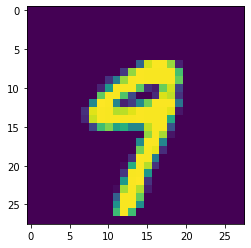

In [33]:
# Does it work on almost all examples?
w1 = model.L1.weight.detach().numpy()
w2 = model.L2.weight.detach().numpy()
img = x_test[8700]
img = img.reshape(1, -1).dot(w1.T)
img = np.maximum(0, img)
img = img.dot(w2.T)
np.argmax(img), imshow(x_test[8700])



In [ ]:
# Implement model with ADAM using numpy?